# Laboratorio 02: Regresión Lineal Múltiple
## Predicción de Precios de Viviendas (House Sales in King County)
**Estudiante:** Karen Villarpando Olmedo

**Dataset:** 21,613 registros (m) y más de 80 variables predictoras (n)

In [31]:
# Ejercicio de programación Regresión Lineal Multiple
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

# (Opcional) Conectar con Drive si tienes el archivo ahí
# from google.colab import drive
# drive.mount("/content/gdrive")

2. Cargar Datos (pandas)

In [32]:
# Cargar datos con Pandas (asegúrate de que el archivo se llame así en tu Colab)
ruta = 'kc_house_data.csv'
df = pd.read_csv(ruta)

In [33]:
# Limpieza rápida: Borramos nulos, el ID y la fecha (no son matemáticos)
df = df.dropna()
df = df.drop(['id', 'date'], axis=1)

In [34]:
# PARA n>=20: Convertimos el código postal en decenas de columnas
df = pd.get_dummies(df, columns=['zipcode'], drop_first=True, dtype=float)

In [35]:
# Separar X (Características de la casa) e Y (Precio)
y = df['price'].values
X = df.drop('price', axis=1).values
m = len(y)

print(f"Total de datos (casas) (m): {m}")
print(f"Total de predictoras (n): {X.shape[1]}\n")

print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y (Precio)'))
print('-'*30)
for i in range(10):
    print('{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

Total de datos (casas) (m): 21613
Total de predictoras (n): 86

  X[:,0] X[:, 1]y (Precio)
------------------------------
       3       1    221900
       3       2    538000
       2       1    180000
       4       3    604000
       3       2    510000
       4       4   1225000
       3       2    257500
       3       2    291850
       3       1    229500
       3       2    323000


3. Normalizacion

In [24]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1 # Evita división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos X
X_norm, mu, sigma = featureNormalize(X)

# Añadimos la columna de unos al principio (Sesgo theta_0)
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y (Precio)'))
print('-'*30)
for i in range(10):
    print('{:8.3f}{:8.3f}{:10.0f}'.format(X_ready[i, 0], X_ready[i, 1], y[i]))

  X[:,0] X[:, 1]y (Precio)
------------------------------
   1.000  -0.399    221900
   1.000  -0.399    538000
   1.000  -1.474    180000
   1.000   0.676    604000
   1.000  -0.399    510000
   1.000   0.676   1225000
   1.000  -0.399    257500
   1.000  -0.399    291850
   1.000  -0.399    229500
   1.000  -0.399    323000


4. Funciones del Descenso

In [25]:
def computeCostMulti(X, y, theta):
    m = len(y)
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = len(y)
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

5. Ejecucion y Grafica

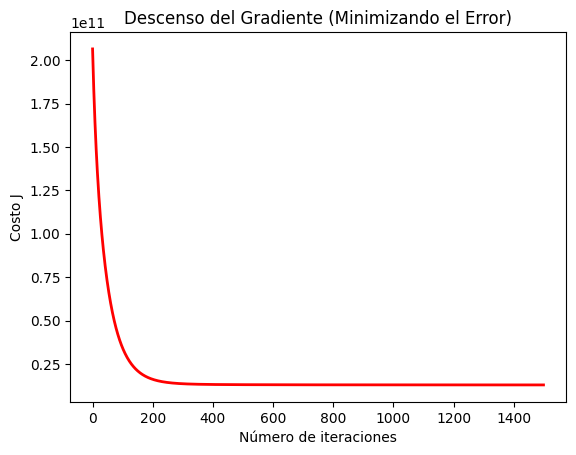

Theta calculado por el descenso por el gradiente:
 [540087.98856732 -24664.72754129  19604.97565017  87545.76319646
  10149.74047982] ...


In [26]:
# Elegir algún valor para alpha (tasa de aprendizaje)
alpha = 0.01
num_iters = 1500

# Inicializa theta en ceros y ejecuta el entrenamiento
theta_inicial = np.zeros(X_ready.shape[1])
theta_gd, J_history = gradientDescentMulti(X_ready, y, theta_inicial, alpha, num_iters)

# Grafica la convergencia del costo (Exigencia del eCampus)
plt.plot(np.arange(len(J_history)), J_history, lw=2, color='red')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Descenso del Gradiente (Minimizando el Error)')
plt.show()

print('Theta calculado por el descenso por el gradiente:\n', theta_gd[:5], '...') # Mostramos solo 5 para no saturar

6. Inferencia (Prediccion)

In [27]:
# Estimar el precio para una mansión inventada
casa_nueva = mu.copy()
casa_nueva[0] = 6     # 6 Dormitorios
casa_nueva[1] = 4     # 4 Baños
casa_nueva[2] = 5000  # 5000 Pies cuadrados de espacio

# Normalizamos obligatoriamente
casa_norm = (casa_nueva - mu) / sigma
casa_lista = np.concatenate([[1], casa_norm])

prediccion_precio = np.dot(casa_lista, theta_gd)
print(f"Precio estimado de la casa (Descenso por el Gradiente): ${prediccion_precio:,.2f}")

Precio estimado de la casa (Descenso por el Gradiente): $796,703.99


7. Ecuacion de la Normal

In [28]:
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

8. Ejecucion Ecuacion Normal e Inferencia

In [29]:
# Calcula los parametros con la ecuación de la normal (AQUÍ NO SE NORMALIZA)
X_orig_con_unos = np.concatenate([np.ones((m, 1)), X], axis=1)

theta_normal = normalEqn(X_orig_con_unos, y)
print('Theta calculado por ecuación normal:\n', theta_normal[:5], '...')

# Estimar con la Ecuación de la Normal (Usamos los datos crudos, sin mu ni sigma)
casa_nueva_normal = np.concatenate([[1], casa_nueva])
prediccion_normal = np.dot(casa_nueva_normal, theta_normal)

print(f"Precio estimado de la casa (Ecuación Normal): ${prediccion_normal:,.2f}")

Theta calculado por ecuación normal:
 [-2.10081927e+07  2.44147986e+06 -5.99627427e+06  1.90187562e+04
 -5.09889925e-01] ...
Precio estimado de la casa (Ecuación Normal): $50,505,245.24
